<a href="https://colab.research.google.com/github/sujal003-hue/Upgrade-Capstone-Project/blob/main/Supply_Chain_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

# **Loading Our Dataset**

In [ ]:
df= pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding='latin-1')

# **Display Top 5 Rows Of Our Dataset**

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


# **Display Last 5 Rows Of Our Dataset**

In [ ]:
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
6009,CASH,2,1,191.250000,503.290008,Late delivery,1,68,Garden,San Jose,...,NaN,1355.0,68.0,NaN,http://images.acmesports.sports/Lawn+mower,Lawn mower,532.580017,0.0,11/16/2017 2:23,First Class
6010,CASH,2,1,227.039993,463.339996,Late delivery,1,68,Garden,Opa Locka,...,NaN,1355.0,68.0,NaN,http://images.acmesports.sports/Lawn+mower,Lawn mower,532.580017,0.0,11/19/2017 10:37,First Class
6011,CASH,2,1,-15.220000,21.740000,Late delivery,1,40,Accessories,Lilburn,...,NaN,906.0,40.0,NaN,http://images.acmesports.sports/Team+Golf+Tenn...,Team Golf Tennessee Volunteers Putter Grip,24.990000,0.0,11/19/2016 19:42,First Class
6012,CASH,2,1,3.320000,20.740000,Late delivery,1,40,Accessories,Fairfield,...,NaN,885.0,40.0,NaN,http://images.acmesports.sports/Team+Golf+St.+...,Team Golf St. Louis Cardinals Putter Grip,24.990000,0.0,1/4/2016 14:33,First Class
6013,CASH,2,1,-0.790000,20.740000,Late delivery,1,40,Accessories,Dallas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Get The Information About Our Dataset Like Name Of Each Column Of Our Dataset**

In [ ]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

# **Exploratory Data Analysis (EDA)**

**Get The Information About Our Datase Like Number Of Columns, Rows And Check The Duplicate Values In Each Of The Columns.**

In [ ]:
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (6014, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product 

In [ ]:
(df['Benefit per order'] == df['Benefit per order']).value_counts()

,count
Benefit per order,
True,6014


**Droping the columns that are either fully missing, redundant, or have only one value (and thus no variance)**

In [ ]:
columns_to_drop = ['Product Description', 'Order Zipcode']

In [ ]:
df = df.drop(columns=columns_to_drop)

# **Standard Date Conversion**

In [ ]:
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
  df[c] = pd.to_datetime(df[c])

**After data cleaning, let's check the overview again to see how the dataset has changed**

In [ ]:
df.dropna(inplace=True)
print('rows, cols:', df.shape)
print('\nMissing values (top5):')
print(df.isna().sum().sort_values(ascending=False).head())

rows, cols: (6013, 58)

Missing values (top5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
dtype: int64


**Value counts for categorical columns with low cardinality**

In [ ]:
for col in df.columns:
    if df[col].nunique() <10:
        print(f'\n{col}.value_counts:')
        print(df[col].value_counts())


Type.value_counts:
Type
DEBIT       2436
TRANSFER    1914
PAYMENT      899
CASH         764
Name: count, dtype: int64

Days for shipping (real).value_counts:
Days for shipping (real)
2    1740
4    1051
5    1039
3    1036
6    1004
1      84
0      59
Name: count, dtype: int64

Days for shipment (scheduled).value_counts:
Days for shipment (scheduled)
4    4114
2    1061
1     695
0     143
Name: count, dtype: int64

Delivery Status.value_counts:
Delivery Status
Late delivery        3107
Advance shipping     1547
Shipping on time     1037
Shipping canceled     322
Name: count, dtype: int64

Late_delivery_risk.value_counts:
Late_delivery_risk
1    3107
0    2906
Name: count, dtype: int64

Customer Country.value_counts:
Customer Country
EE. UU.        3590
Puerto Rico    2423
Name: count, dtype: int64

Customer Email.value_counts:
Customer Email
XXXXXXXXX    6013
Name: count, dtype: int64

Customer Password.value_counts:
Customer Password
XXXXXXXXX    6013
Name: count, dtype: int64

Cus

# **Check The Null Values In Our Dataset**

In [ ]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


# **Calculating order processing time and delay (with statistical measure of the dataset)**

In [ ]:
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipping (real)']
df['Is_Delayed'] = df['Delay'] > 0
df['Order_month'] = df['order date (DateOrders)'].dt.month
df['Order_day'] = df['order date (DateOrders)'].dt.day
df['Order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Product Card Id,Product Category Id,Product Price,Product Status,shipping date (DateOrders),Order Processing Time,Delay,Order_month,Order_day,Order_hour
count,6013.000000,6013.000000,6013.000000,6013.000000,6013.000000,6013.000000,6013.000000,6013.000000,6013.000000,6013.000000,...,6013.000000,6013.000000,6013.000000,6013.0,6013,6013.000000,6013.000000,6013.000000,6013.000000,6013.000000
mean,3.674538,3.205222,21.816524,184.662418,0.516714,27.153501,7566.196408,34841.346250,4.382837,29.355863,...,568.712623,27.153501,125.306003,0.0,2016-06-27 22:05:28.987194368,3.660569,-0.013970,6.256278,15.422917,11.444038
min,0.000000,0.000000,-1140.790039,9.260000,0.000000,2.000000,6.000000,603.000000,2.000000,17.982491,...,24.000000,2.000000,11.290000,0.0,2015-01-04 03:51:00,0.000000,-1.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,6.150000,99.580002,0.000000,17.000000,3674.000000,725.000000,3.000000,18.261364,...,365.000000,17.000000,50.000000,0.0,2015-09-18 15:45:00,2.000000,0.000000,3.000000,8.000000,5.000000
50%,4.000000,4.000000,29.879999,163.770004,1.000000,18.000000,7163.000000,15642.000000,4.000000,32.959442,...,403.000000,18.000000,59.990002,0.0,2016-04-26 11:03:00,4.000000,0.000000,6.000000,15.000000,11.000000
75%,5.000000,4.000000,67.500000,262.200012,1.000000,37.000000,10563.000000,77840.000000,5.000000,38.960819,...,828.000000,37.000000,129.990005,0.0,2017-04-09 11:00:00,5.000000,0.000000,10.000000,23.000000,17.000000
max,6.000000,4.000000,599.250000,1417.500000,1.000000,76.000000,20755.000000,98632.000000,12.000000,47.843224,...,1363.000000,76.000000,1500.000000,0.0,2018-02-05 14:43:00,6.000000,0.000000,12.000000,31.000000,23.000000
std,1.532204,1.222757,103.922074,121.758017,0.499762,18.984767,4919.471884,37593.082439,1.753748,9.821678,...,374.568960,18.984767,134.718040,0.0,NaN,1.560822,0.117375,3.760770,8.806559,6.935839


In [ ]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
False,6013


**Now, Check The Name Of Each Of Column In Our Dataset**

In [ ]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Image',
       'Product Na

# **Profitability Flag Based on Order Profit Per Order**

In [ ]:
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Neutral'))
df['Profitability Flag'].value_counts()

,count
Profitability Flag,
Profit,4843
Loss,1136
Neutral,34


# **Data Visualization Through Piechart**

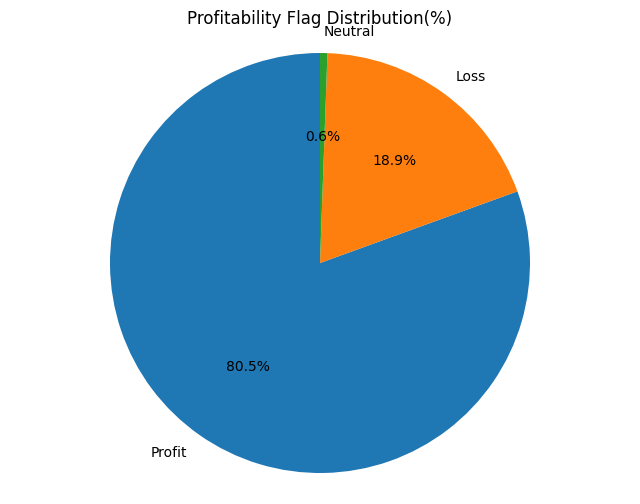

In [ ]:
profit_counts = df['Profitability Flag'].value_counts(normalize=True)
plt.figure(figsize=(8, 6))
plt.pie(profit_counts, labels=profit_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Profitability Flag Distribution(%)')
plt.axis('equal')
plt.show()

In [ ]:
def format_fund(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.0f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Delivery'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Delivery']/metrics['Total Orders']))*100
metrics['Late Delivery %'] = float(metrics['Late Delivery'])/metrics['Total Orders'] * 100
metrics['Total Profit'] = df['Order Profit Per Order'].sum()
metrics['Total Profit Formatted'] = format_fund(metrics['Total Profit'])
metrics['Total loss due to delays'] = format_fund(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v , float):
        print(f'{k}: {v:.2f}')
    else:
        print(f'{k}: {v}')


--- Business KPIs ---

Total Orders: 6013
Late Delivery: 0
90% Delay (days): nan
On time Delivery %: 100.00
Late Delivery %: 0.00
Total Profit: 131182.76
Total Profit Formatted: 131K $
Total loss due to delays: 0 $


# **Profitability v/s Delivery Time Analysis**

In [ ]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit="mean",
        total_profit="sum",
        Order_count="count"
    )
    .reset_index()
)

In [ ]:
profit_metrics

,Delay,mean_profit,total_profit,Order_count
0,-1,24.68250,2073.330005,84
1,0,21.77592,129109.430244,5929


In [ ]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
    ).reset_index()

In [ ]:
delay_distribution

,Delay,proportion
0,-1,1.396973
1,0,98.603027


# **Data Visualization Through Barplot**


Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,Order_count
0,-1,24.7,2073.3,84
1,0,21.8,129109.4,5929



Delay Distribution (%):


,Delay_Days,Percentage
0,-1,1.396973
1,0,98.603027


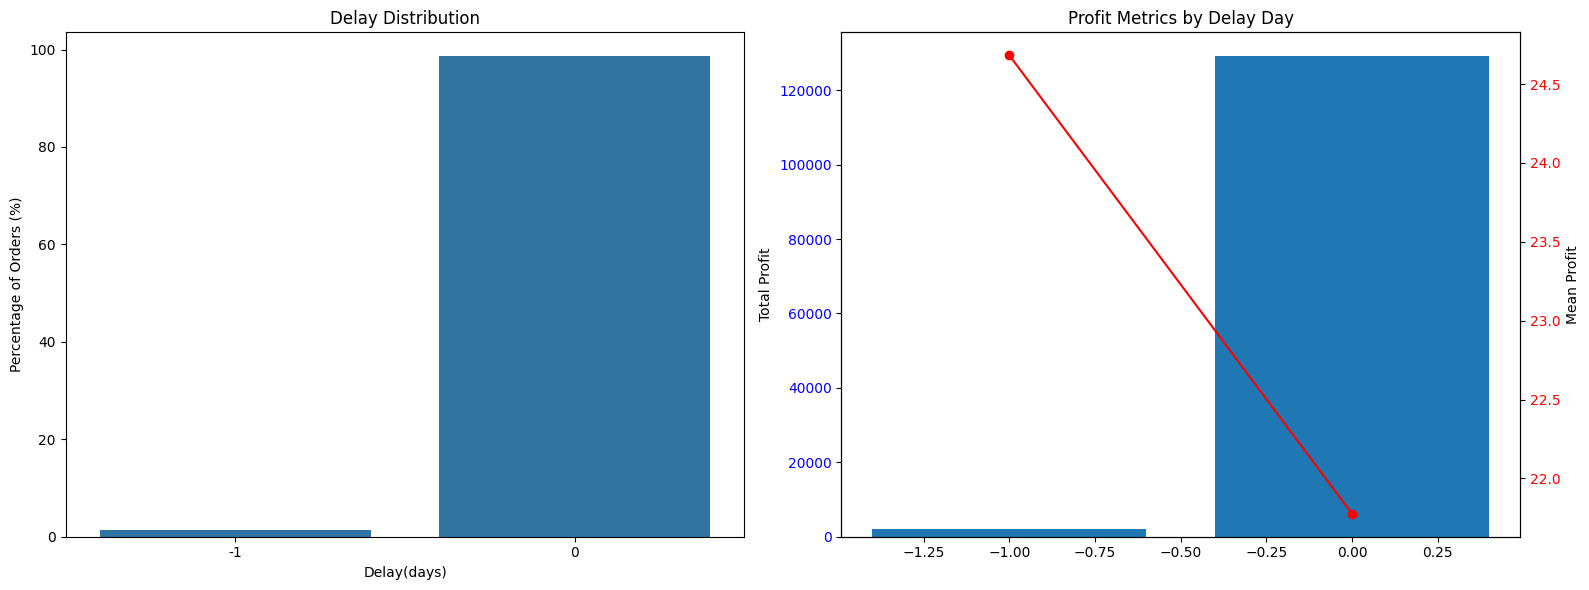

In [ ]:
delay_distribution.columns = ['Delay_Days', 'Percentage']
print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay(days)')
ax1.set_ylabel('Percentage of Orders (%)')

ax2.set_ylabel("Total Profit")
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], label="Total Profit")
ax2.tick_params(axis='y', labelcolor='blue')

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit")
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label="Mean Profit", color='red') # Using a default color
ax3.tick_params(axis='y', labelcolor='red')

plt.title('Profit Metrics by Delay Day')
plt.tight_layout()
plt.show()

# **Bottleneck Detection**

### **Bottleneck Analysis by Shipping Mode**

,Shipping Mode,Late_Delivery_Percentage
0,First Class,99.424460
1,Same Day,56.643357
2,Second Class,80.018850
3,Standard Class,36.120564


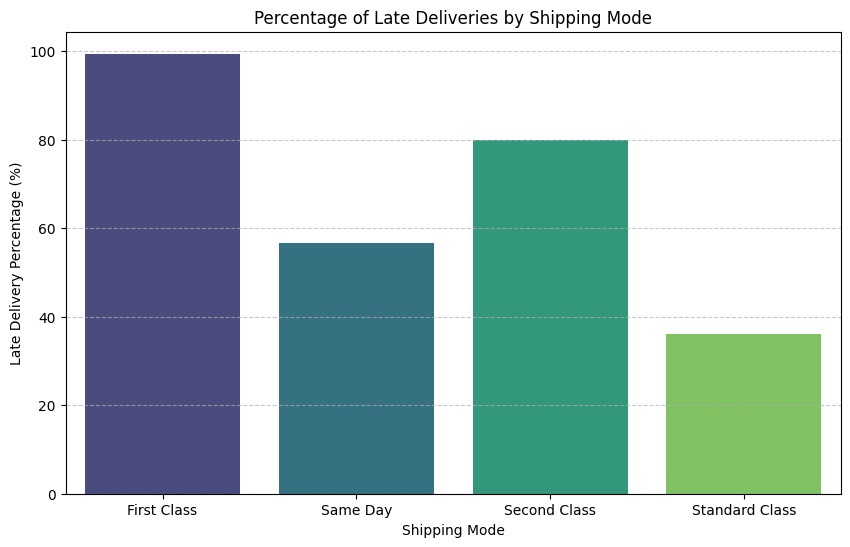

In [ ]:
bottleneck_shipping_mode = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().mul(100).reset_index()
bottleneck_shipping_mode.columns = ['Shipping Mode', 'Late_Delivery_Percentage']
display(bottleneck_shipping_mode)

plt.figure(figsize=(10, 6))
sns.barplot(x='Shipping Mode', y='Late_Delivery_Percentage', data=bottleneck_shipping_mode, palette='viridis')
plt.title('Percentage of Late Deliveries by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Data Visualization Through Barplot With "Order Region" Column**

,Order Region,Late_Delivery_Percentage
0,Canada,17.391304
1,Caribbean,52.290076
2,Central Africa,53.658537
3,Central America,50.974026
4,Central Asia,60.714286
5,East Africa,51.282051
6,East of USA,47.916667
7,Eastern Asia,50.368550
8,Eastern Europe,55.223881
9,North Africa,44.927536


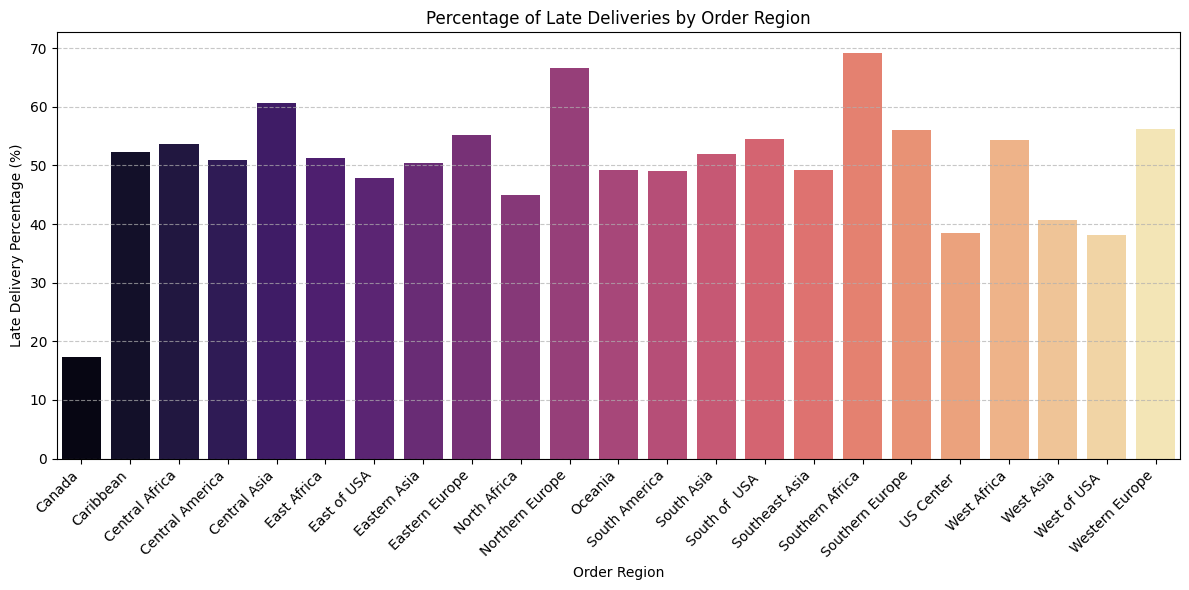

In [ ]:
bottleneck_order_region = df.groupby('Order Region')['Late_delivery_risk'].mean().mul(100).reset_index()
bottleneck_order_region.columns = ['Order Region', 'Late_Delivery_Percentage']
display(bottleneck_order_region)

plt.figure(figsize=(12, 6))
sns.barplot(x='Order Region', y='Late_Delivery_Percentage', data=bottleneck_order_region, palette='magma')
plt.title('Percentage of Late Deliveries by Order Region')
plt.xlabel('Order Region')
plt.ylabel('Late Delivery Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Again, Doing Data Visualization Through Barplot With "Department Name" Column**

,Department Name,Late_Delivery_Percentage
0,Apparel,56.110521
1,Book Shop,65.217391
2,Discs Shop,55.952381
3,Fan Shop,60.000000
4,Fitness,54.043768
5,Footwear,42.150171
6,Golf,43.037037
7,Health and Beauty,71.428571
8,Outdoors,45.229682
9,Pet Shop,73.684211


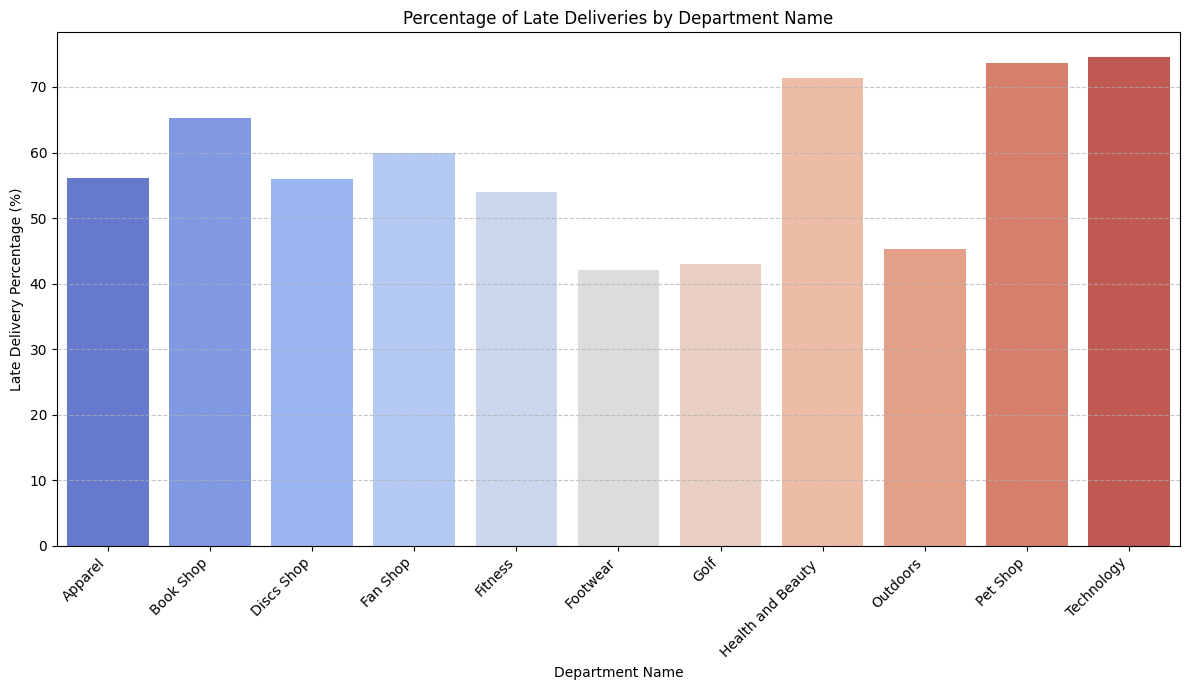

In [ ]:
bottleneck_department = df.groupby('Department Name')['Late_delivery_risk'].mean().mul(100).reset_index()
bottleneck_department.columns = ['Department Name', 'Late_Delivery_Percentage']
display(bottleneck_department)

plt.figure(figsize=(12, 7))
sns.barplot(x='Department Name', y='Late_Delivery_Percentage', data=bottleneck_department, palette='coolwarm')
plt.title('Percentage of Late Deliveries by Department Name')
plt.xlabel('Department Name')
plt.ylabel('Late Delivery Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Time-Based Analysis**

,Month,Late_Delivery_Percentage
0,1,50.985222
1,2,49.186257
2,3,50.537634
3,4,52.370203
4,5,48.598131
5,6,50.410959
6,7,53.529412
7,8,55.140187
8,9,51.292247
9,10,57.582418


,Month,Total_Sales
0,1,178099.782264
1,2,104131.842118
2,3,102239.441943
3,4,91409.071749
4,5,83765.911507
5,6,71137.411289
6,7,63681.451068
7,8,85495.501611
8,9,104974.371389
9,10,106687.061538


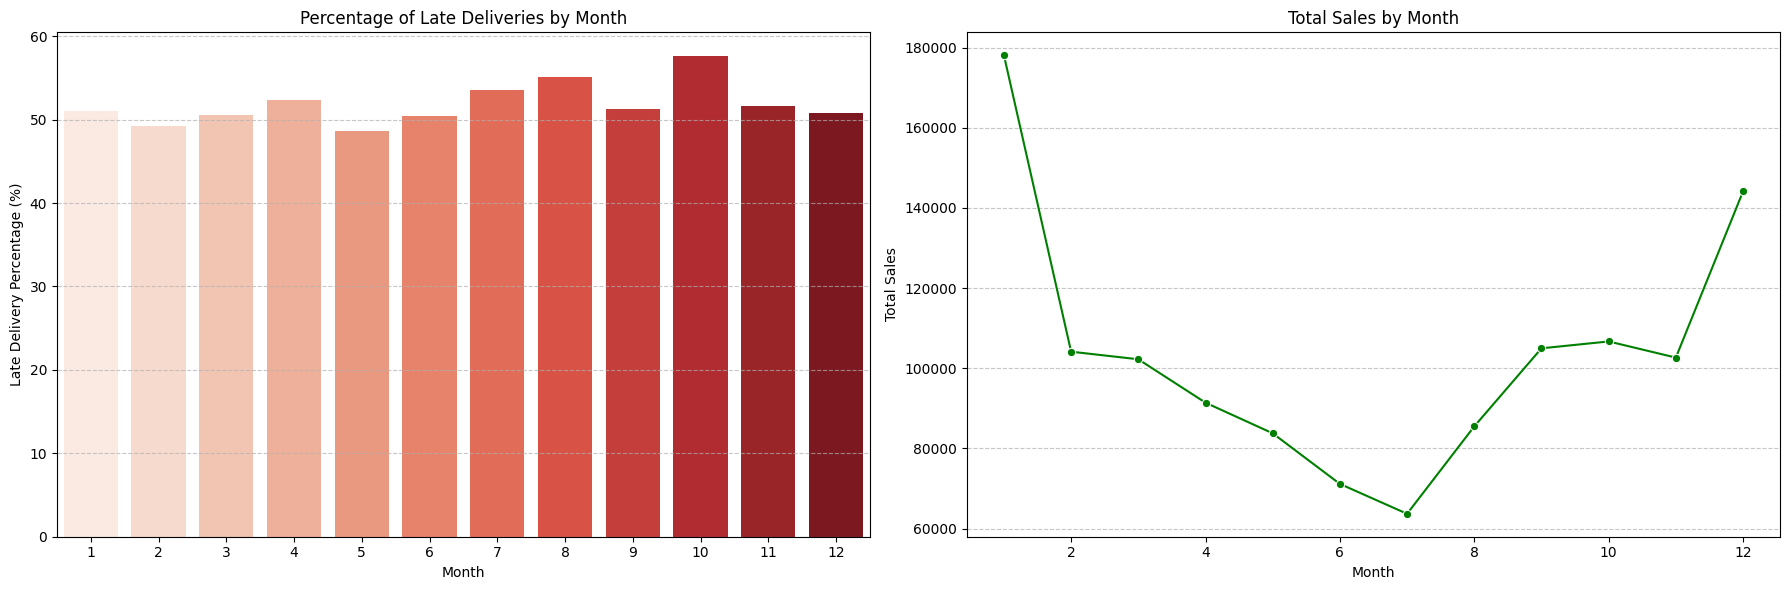

In [ ]:
# Analyze late delivery percentage by month
monthly_late_delivery = df.groupby('Order_month')['Late_delivery_risk'].mean().mul(100).reset_index()
monthly_late_delivery.columns = ['Month', 'Late_Delivery_Percentage']
display(monthly_late_delivery)

# Analyze total sales by month
monthly_sales = df.groupby('Order_month')['Sales'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total_Sales']
display(monthly_sales)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Late Delivery Percentage by Month
sns.barplot(x='Month', y='Late_Delivery_Percentage', data=monthly_late_delivery, palette='Reds', ax=axes[0])
axes[0].set_title('Percentage of Late Deliveries by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Late Delivery Percentage (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Total Sales by Month
sns.lineplot(x='Month', y='Total_Sales', data=monthly_sales, marker='o', color='green', ax=axes[1])
axes[1].set_title('Total Sales by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Sales')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Making Comparison Through Barplot Between Total Sales In Week With Late Delivery In Week**

,Day_of_Week,Late_Delivery_Percentage,Day_of_Week_Name
0,0,52.014218,Monday
1,1,54.000000,Tuesday
2,2,49.468713,Wednesday
3,3,52.659574,Thursday
4,4,49.209932,Friday
5,5,51.657143,Saturday
6,6,52.927669,Sunday


,Day_of_Week,Total_Sales,Day_of_Week_Name
0,0,180196.992813,Monday
1,1,143971.472705,Tuesday
2,2,169245.672974,Wednesday
3,3,197657.633508,Thursday
4,4,186283.562896,Friday
5,5,178018.282883,Saturday
6,6,183028.662806,Sunday


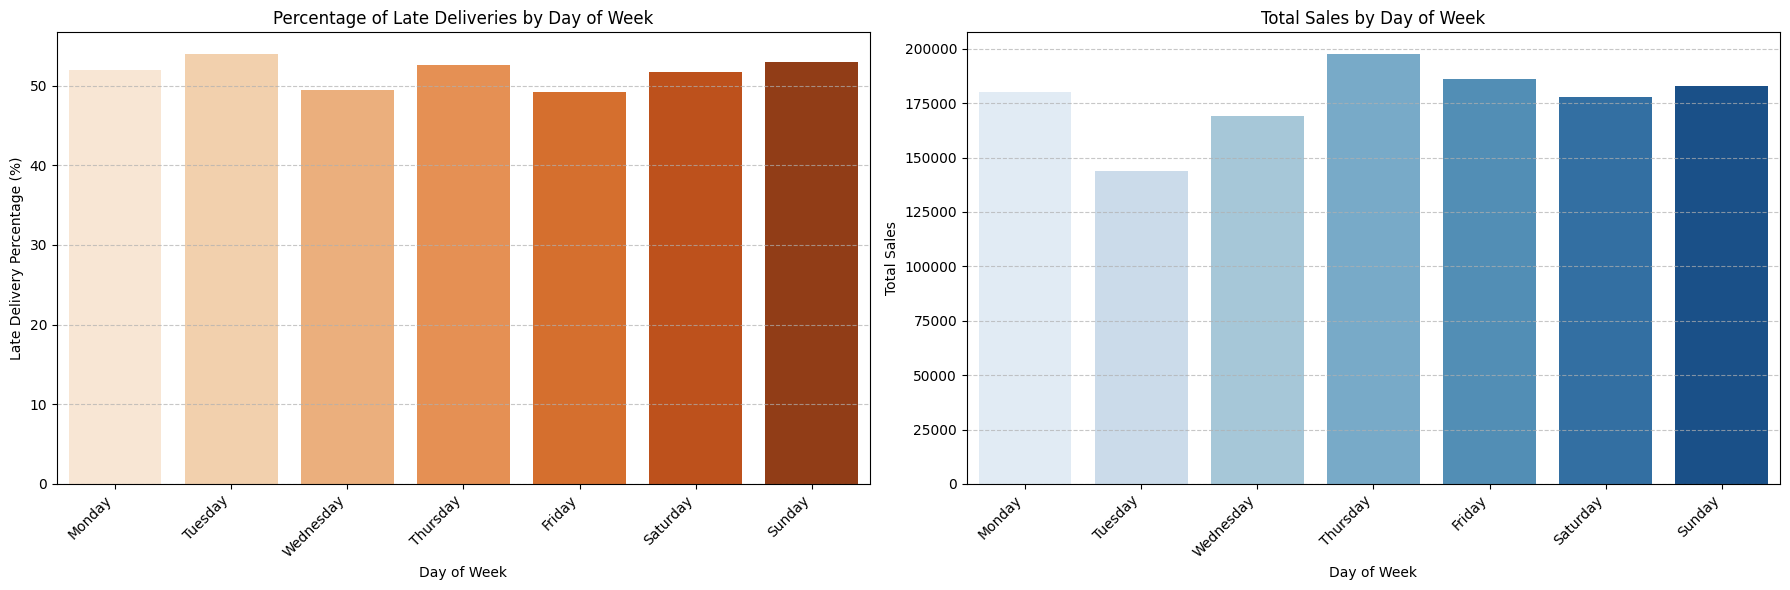

In [ ]:
# Extract day of the week (Monday=0, Sunday=6)
df['Order_day_of_week'] = df['order date (DateOrders)'].dt.dayofweek

# Analyze late delivery percentage by day of the week
daily_late_delivery = df.groupby('Order_day_of_week')['Late_delivery_risk'].mean().mul(100).reset_index()
daily_late_delivery.columns = ['Day_of_Week', 'Late_Delivery_Percentage']

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_late_delivery['Day_of_Week_Name'] = daily_late_delivery['Day_of_Week'].map(lambda x: day_names[x])
display(daily_late_delivery)

# Analyze total sales by day of the week
daily_sales = df.groupby('Order_day_of_week')['Sales'].sum().reset_index()
daily_sales.columns = ['Day_of_Week', 'Total_Sales']
daily_sales['Day_of_Week_Name'] = daily_sales['Day_of_Week'].map(lambda x: day_names[x])
display(daily_sales)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Late Delivery Percentage by Day of Week
sns.barplot(x='Day_of_Week_Name', y='Late_Delivery_Percentage', data=daily_late_delivery, palette='Oranges', ax=axes[0])
axes[0].set_title('Percentage of Late Deliveries by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Late Delivery Percentage (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot Total Sales by Day of Week
sns.barplot(x='Day_of_Week_Name', y='Total_Sales', data=daily_sales, palette='Blues', ax=axes[1])
axes[1].set_title('Total Sales by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Sales')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

,Hour,Late_Delivery_Percentage
0,0,48.962656
1,1,53.305785
2,2,45.945946
3,3,49.300699
4,4,48.638132
5,5,44.401544
6,6,52.830189
7,7,53.191489
8,8,50.179211
9,9,51.459854


,Hour,Total_Sales
0,0,47994.460737
1,1,49221.580739
2,2,52658.691014
3,3,61843.651060
4,4,52357.130939
5,5,55701.400998
6,6,45413.040687
7,7,46396.480810
8,8,56532.750900
9,9,55371.810956


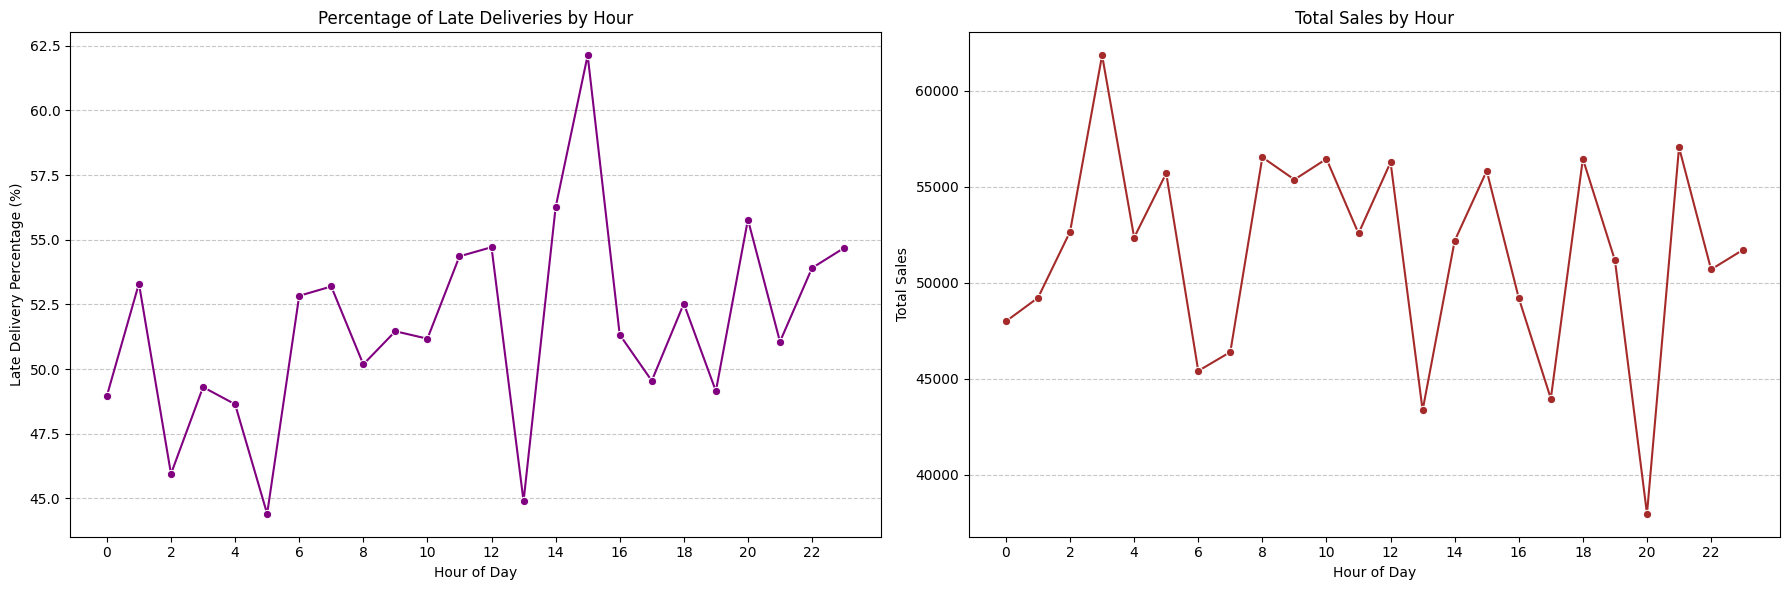

In [ ]:
# Analyze late delivery percentage by hour
hourly_late_delivery = df.groupby('Order_hour')['Late_delivery_risk'].mean().mul(100).reset_index()
hourly_late_delivery.columns = ['Hour', 'Late_Delivery_Percentage']
display(hourly_late_delivery)

# Analyze total sales by hour
hourly_sales = df.groupby('Order_hour')['Sales'].sum().reset_index()
hourly_sales.columns = ['Hour', 'Total_Sales']
display(hourly_sales)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Late Delivery Percentage by Hour
sns.lineplot(x='Hour', y='Late_Delivery_Percentage', data=hourly_late_delivery, marker='o', color='purple', ax=axes[0])
axes[0].set_title('Percentage of Late Deliveries by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Late Delivery Percentage (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_xticks(range(0, 24, 2)) # Set x-ticks for every other hour

# Plot Total Sales by Hour
sns.lineplot(x='Hour', y='Total_Sales', data=hourly_sales, marker='o', color='brown', ax=axes[1])
axes[1].set_title('Total Sales by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Total Sales')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticks(range(0, 24, 2)) # Set x-ticks for every other hour

plt.tight_layout()
plt.show()

# **Store Feature Matrix In X And Response (Target) In Vector y**

In [ ]:
y = df['Late_delivery_risk']

columns_to_drop_for_X = [
    'Late_delivery_risk', 'Delivery Status', 'Delay', 'Is_Delayed', 'Order Processing Time',
    'order date (DateOrders)', 'shipping date (DateOrders)',
    'Customer Email', 'Customer Password', 'Product Status',
    'Order Id', 'Customer Id', 'Product Card Id', 'Product Category Id',
    'Department Id', 'Category Id', 'Order Customer Id', 'Product Image',
    'Customer Fname', 'Customer Lname',
    'Customer Street', 'Customer City', 'Customer State', 'Customer Zipcode',
    'Latitude', 'Longitude'
]
X = df.drop(columns=columns_to_drop_for_X, errors='ignore')

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (6013, 33)
Shape of y: (6013,)


In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical columns: {cat_cols}')

for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

X = X.drop(columns=cat_cols)

print(f'Shape after frequency encoding and dropping original categorical columns: {X.shape}')

Categorical columns: ['Type', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode', 'Profitability Flag']
Shape after frequency encoding and dropping original categorical columns: (6013, 33)


# **Splitting The Dataset Into Train Set And Test Set**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4810, 33)
X_test shape: (1203, 33)
y_train shape: (4810,)
y_test shape: (1203,)


In [ ]:
y.value_counts()

,count
Late_delivery_risk,
1,3107
0,2906


# **Balancing The Training Data Using SMOTE**

In [ ]:
print("Before Balancing(train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After Balancing (train):", Counter(y_train_bal))

Before Balancing(train): Counter({1: 2485, 0: 2325})
After Balancing (train): Counter({1: 2485, 0: 2485})


In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n---{model_name}---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
    print(f"Precision: {precision_score(y_true, y_pred)}")
    print(f"Recall: {recall_score(y_true, y_pred)}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")

# **Fit Random Forest Model On Balance Data**

In [ ]:
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


---Random Forest Classifier---
Accuracy: 0.9950124688279302
Precision: 0.9904458598726115
Recall: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       581
           1       0.99      1.00      1.00       622

    accuracy                           1.00      1203
   macro avg       1.00      0.99      1.00      1203
weighted avg       1.00      1.00      1.00      1203



# **Conclusion**

**To conclude by saying that we perform various data analysis algorithm as above mentioned. Firstly, we load our dataset, then we analysis our dataset like checking number of rows, columns, checking the null values in our dataset, name of each columns and statistical measure of our dataset. We also perform data visualization in our dataset which helps to understand this data easily. Then we split our dataset into train set and test set and by using Random Forest Classifier we fit the balance data and predict the accuracy score, precision score, recall score and classification report.**